In [1]:
# ============================================================
# CELL 1: Import all libraries we need
# ============================================================

# os: lets us work with files and folders (like cd, dir commands)
import os

# pathlib: modern way to work with file paths in Python
# Path objects are smarter than plain strings for file operations
from pathlib import Path

# numpy: fast math library — arrays, statistics, random numbers
import numpy as np

# pandas: works with tables of data (like Excel but in Python)
# DataFrame = a table with rows and columns
import pandas as pd

# matplotlib: draws charts and graphs
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# seaborn: prettier charts built on top of matplotlib
import seaborn as sns

# PIL (Pillow): opens, edits, saves image files
from PIL import Image

# warnings: suppress unimportant warning messages
import warnings
warnings.filterwarnings('ignore')

# Set a consistent style for all our charts
plt.style.use('seaborn-v0_8-darkgrid')

# Set figure size default so charts aren't tiny
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print("✓ All libraries imported successfully!")

✓ All libraries imported successfully!


In [2]:
# ============================================================
# CELL 2: Locate the dataset and handle the nested folder
# ============================================================

# Path() creates a path object — smarter than plain strings
# '..' means go up one folder level
# So this goes: notebooks → ml_training → project root → data/raw
DATA_ROOT = Path('../../data/raw')

# As we noticed yesterday, the data is nested:
# data/raw/PlantVillage/PlantVillage/ ← actual disease folders
# Let's find the correct path automatically

def find_dataset_path(root):
    """
    Automatically finds where the disease class folders are.
    
    Args:
        root: Path to start searching from
    
    Returns:
        Path to the folder containing disease class subfolders
    """
    # Walk through all subdirectories
    # root.rglob('*') finds everything recursively
    for path in root.rglob('*'):
        # We're looking for a directory...
        if path.is_dir():
            # ...that contains subdirectories with image files
            subdirs = [x for x in path.iterdir() if x.is_dir()]
            if len(subdirs) >= 10:  # disease folder has 10+ subfolders
                # Check if subdirs contain images
                sample_dir = subdirs[0]
                images = list(sample_dir.glob('*.jpg')) + \
                         list(sample_dir.glob('*.JPG')) + \
                         list(sample_dir.glob('*.png'))
                if len(images) > 0:
                    return path
    return None

# Find the actual dataset path
DATASET_PATH = find_dataset_path(DATA_ROOT)

if DATASET_PATH:
    print(f"✓ Dataset found at: {DATASET_PATH}")
else:
    # Fallback: try known paths manually
    possible_paths = [
        DATA_ROOT / 'PlantVillage' / 'PlantVillage',
        DATA_ROOT / 'PlantVillage',
        DATA_ROOT
    ]
    for path in possible_paths:
        if path.exists():
            DATASET_PATH = path
            print(f"✓ Dataset found at: {DATASET_PATH}")
            break

# Get all disease class folders
# iterdir() lists everything in the folder
# .is_dir() filters to only folders (not files)
# sorted() puts them in alphabetical order
class_folders = sorted([
    f for f in DATASET_PATH.iterdir() 
    if f.is_dir()
])

print(f"✓ Total disease classes found: {len(class_folders)}")
print(f"\nFirst 5 classes:")
for folder in class_folders[:5]:
    print(f"  → {folder.name}")

✓ Dataset found at: ..\..\data\raw\PlantVillage
✓ Total disease classes found: 16

First 5 classes:
  → Pepper__bell___Bacterial_spot
  → Pepper__bell___healthy
  → PlantVillage
  → Potato___Early_blight
  → Potato___healthy


In [3]:
# ============================================================
# CELL 3: Count images in each disease class
# ============================================================

# We'll store all information in a list of dictionaries
# Each dictionary = one row of data about one disease class
dataset_info = []

print("Scanning dataset...")
print("-" * 50)

for class_folder in class_folders:
    # Get all image files in this folder
    # glob() finds files matching a pattern
    # * means "any filename"
    jpg_images  = list(class_folder.glob('*.jpg'))
    jpeg_images = list(class_folder.glob('*.jpeg'))
    JPG_images  = list(class_folder.glob('*.JPG'))
    png_images  = list(class_folder.glob('*.png'))
    
    # Combine all image lists
    all_images = jpg_images + jpeg_images + JPG_images + png_images
    count = len(all_images)
    
    # Parse the folder name to extract plant and disease
    # Folder names look like: "Tomato_Early_blight" or "Potato___healthy"
    folder_name = class_folder.name
    
    # Split by common separators to get plant name
    # Most folders follow pattern: PlantName_DiseaseName
    parts = folder_name.replace('___', '_').replace('__', '_').split('_')
    plant_name = parts[0]  # first part is always the plant
    
    # Determine if healthy or diseased
    is_healthy = 'healthy' in folder_name.lower()
    
    # Store all info in a dictionary
    dataset_info.append({
        'class_name': folder_name,      # full folder name
        'plant': plant_name,            # just the plant (Tomato, Potato, etc.)
        'is_healthy': is_healthy,       # True/False
        'image_count': count,           # number of images
        'sample_image': all_images[0] if all_images else None  # one example
    })
    
    status = "✓ healthy" if is_healthy else "✗ diseased"
    print(f"{status:12} | {count:5} images | {folder_name}")

# Convert list of dictionaries → pandas DataFrame (a table)
df = pd.DataFrame(dataset_info)

print("-" * 50)
print(f"\n📊 DATASET SUMMARY:")
print(f"   Total classes    : {len(df)}")
print(f"   Total images     : {df['image_count'].sum():,}")
print(f"   Healthy classes  : {df['is_healthy'].sum()}")
print(f"   Diseased classes : {(~df['is_healthy']).sum()}")
print(f"   Plants covered   : {df['plant'].nunique()} → {sorted(df['plant'].unique())}")
print(f"\n   Avg images/class : {df['image_count'].mean():.0f}")
print(f"   Min images/class : {df['image_count'].min()} ({df.loc[df['image_count'].idxmin(), 'class_name']})")
print(f"   Max images/class : {df['image_count'].max()} ({df.loc[df['image_count'].idxmax(), 'class_name']})")

Scanning dataset...
--------------------------------------------------
✗ diseased   |  1994 images | Pepper__bell___Bacterial_spot
✓ healthy    |  2955 images | Pepper__bell___healthy
✗ diseased   |     0 images | PlantVillage
✗ diseased   |  2000 images | Potato___Early_blight
✓ healthy    |   304 images | Potato___healthy
✗ diseased   |  2000 images | Potato___Late_blight
✗ diseased   |  2808 images | Tomato__Target_Spot
✗ diseased   |   746 images | Tomato__Tomato_mosaic_virus
✗ diseased   |  6416 images | Tomato__Tomato_YellowLeaf__Curl_Virus
✗ diseased   |  4254 images | Tomato_Bacterial_spot
✗ diseased   |  2000 images | Tomato_Early_blight
✓ healthy    |  3182 images | Tomato_healthy
✗ diseased   |  3817 images | Tomato_Late_blight
✗ diseased   |  1904 images | Tomato_Leaf_Mold
✗ diseased   |  3542 images | Tomato_Septoria_leaf_spot
✗ diseased   |  3352 images | Tomato_Spider_mites_Two_spotted_spider_mite
--------------------------------------------------

📊 DATASET SUMMARY:
   

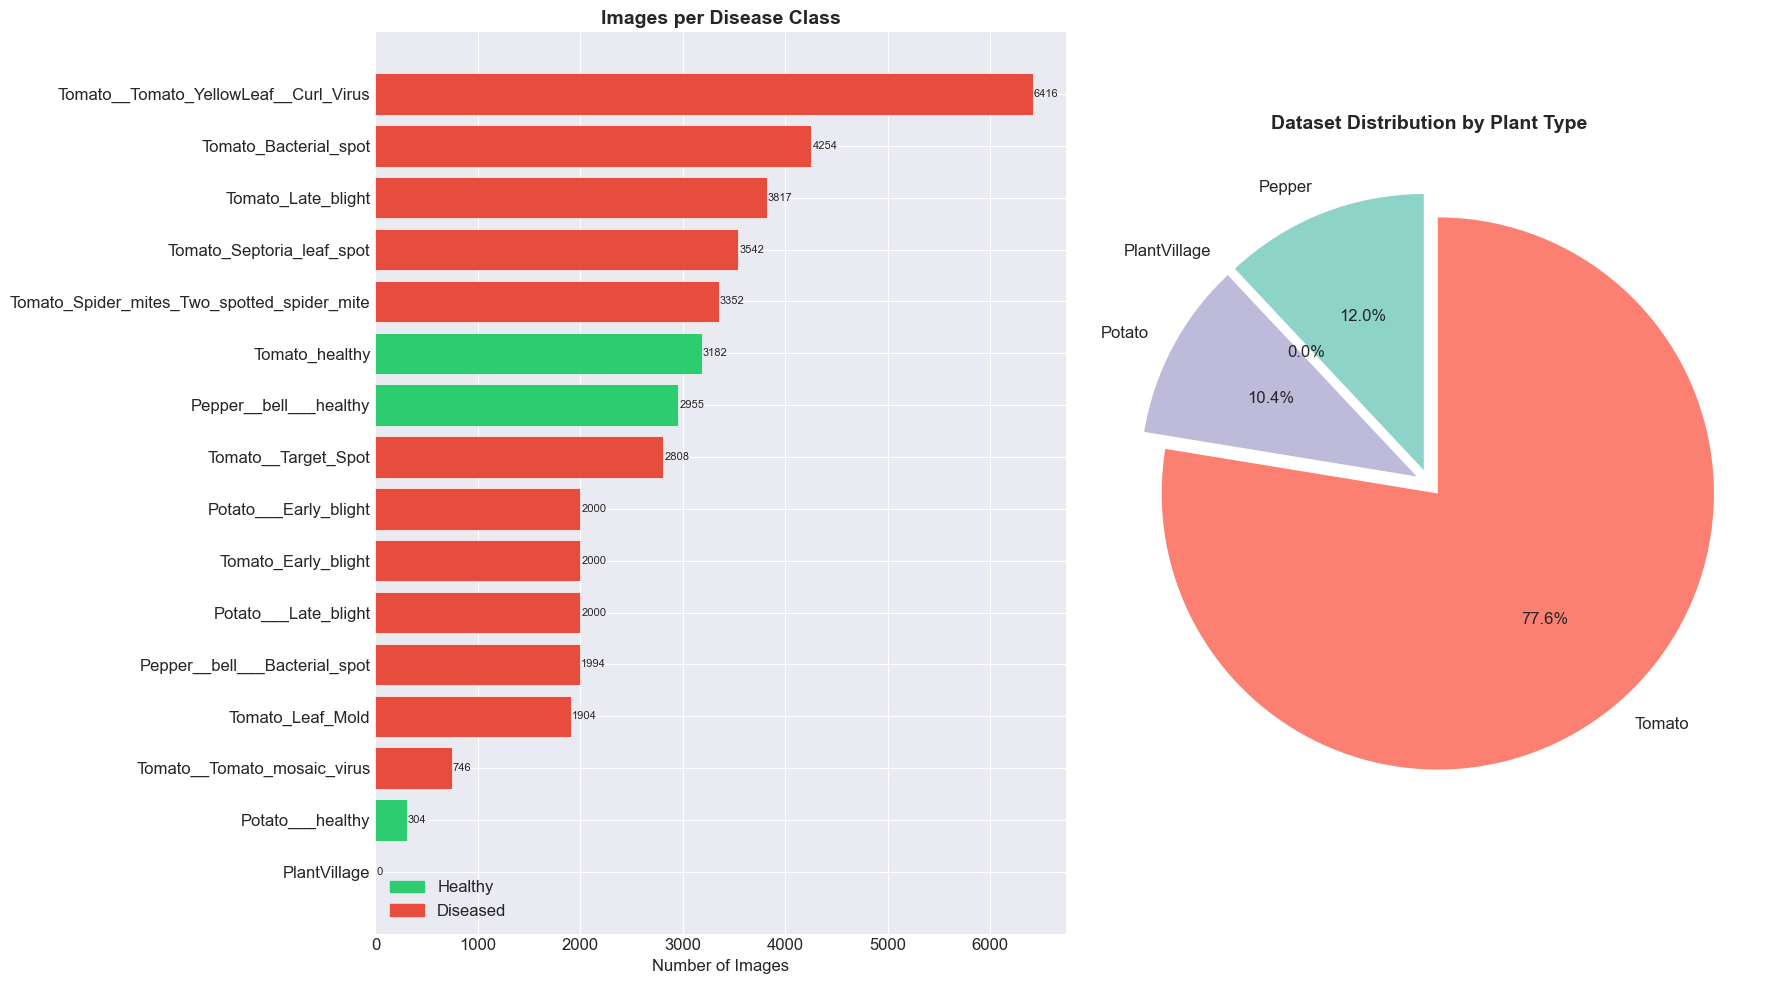

✓ Chart saved to data/class_distribution.png


In [4]:
# ============================================================
# CELL 4: Bar chart — how many images per disease class?
# ============================================================

# Sort by image count (largest first) for better visualization
df_sorted = df.sort_values('image_count', ascending=True)

# Create figure with two subplots side by side
# figsize=(18, 10) = 18 inches wide, 10 inches tall
fig, axes = plt.subplots(1, 2, figsize=(18, 10))

# ---- LEFT CHART: Horizontal bar chart of all classes ----
# Color bars differently for healthy vs diseased
colors = ['#2ecc71' if h else '#e74c3c' for h in df_sorted['is_healthy']]
# '#2ecc71' = green for healthy, '#e74c3c' = red for diseased

bars = axes[0].barh(
    df_sorted['class_name'],    # y-axis: disease names
    df_sorted['image_count'],   # x-axis: image counts
    color=colors,
    edgecolor='white',
    linewidth=0.5
)

# Add value labels at end of each bar
for bar, count in zip(bars, df_sorted['image_count']):
    axes[0].text(
        bar.get_width() + 10,   # x position (just after bar end)
        bar.get_y() + bar.get_height()/2,  # y position (center of bar)
        str(count),
        va='center', fontsize=8
    )

axes[0].set_xlabel('Number of Images')
axes[0].set_title('Images per Disease Class', fontsize=14, fontweight='bold')

# Add legend
healthy_patch = mpatches.Patch(color='#2ecc71', label='Healthy')
disease_patch = mpatches.Patch(color='#e74c3c', label='Diseased')
axes[0].legend(handles=[healthy_patch, disease_patch])

# ---- RIGHT CHART: Pie chart by plant type ----
plant_counts = df.groupby('plant')['image_count'].sum()

# Explode the biggest slice slightly for emphasis
explode = [0.05] * len(plant_counts)

axes[1].pie(
    plant_counts.values,
    labels=plant_counts.index,
    autopct='%1.1f%%',    # show percentage on each slice
    explode=explode,
    startangle=90,
    colors=plt.cm.Set3.colors  # nice color palette
)
axes[1].set_title('Dataset Distribution by Plant Type', 
                   fontsize=14, fontweight='bold')

plt.tight_layout()  # prevents charts from overlapping
plt.savefig('../../data/class_distribution.png', 
            dpi=150, bbox_inches='tight')
plt.show()

print("✓ Chart saved to data/class_distribution.png")

Analyzing image properties (sampling 5 images per class)...
This tells us if images are consistent or need resizing

IMAGE PROPERTIES REPORT

Image dimensions:
  Most common size : 256x256 px
  Width  range     : 256 – 256 px
  Height range     : 256 – 256 px

Color modes found:
  RGB: 75 images

File sizes:
  Average : 17.4 KB
  Smallest: 8.4 KB
  Largest : 26.0 KB


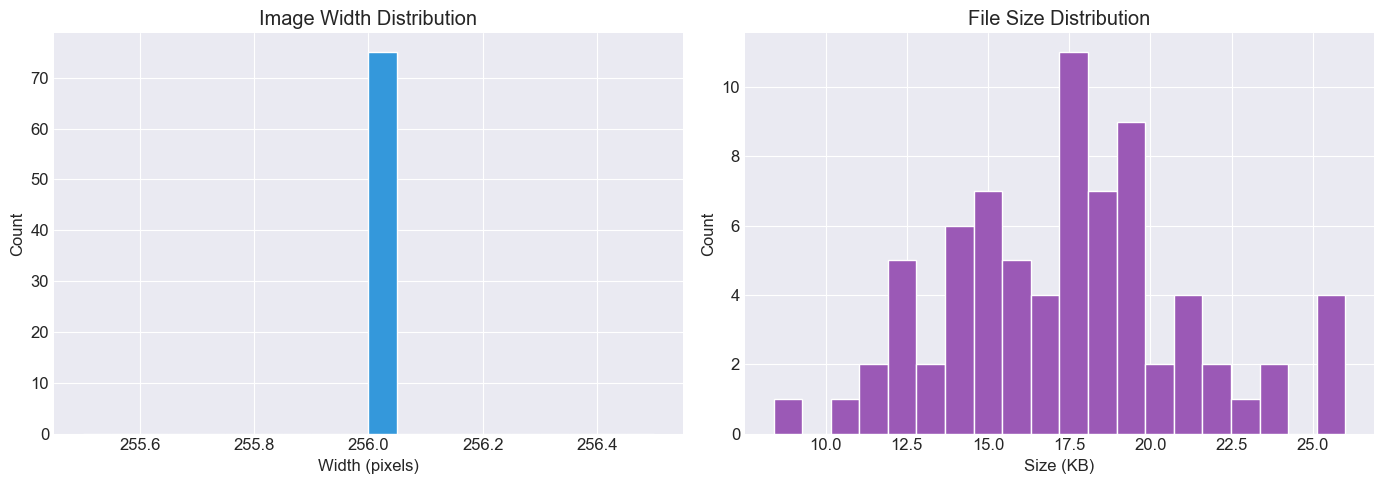

In [5]:
# ============================================================
# CELL 5: Check image sizes, quality, and properties
# ============================================================

print("Analyzing image properties (sampling 5 images per class)...")
print("This tells us if images are consistent or need resizing\n")

image_properties = []

for _, row in df.iterrows():
    class_folder = DATASET_PATH / row['class_name']
    
    # Get all images in this class
    all_imgs = (list(class_folder.glob('*.jpg')) + 
                list(class_folder.glob('*.JPG')) +
                list(class_folder.glob('*.jpeg')) +
                list(class_folder.glob('*.png')))
    
    # Sample up to 5 images per class (don't need to check all)
    sample = all_imgs[:5]
    
    for img_path in sample:
        try:
            # Open the image with PIL
            img = Image.open(img_path)
            
            width, height = img.size  # dimensions in pixels
            mode = img.mode           # 'RGB', 'RGBA', 'L' (grayscale), etc.
            
            # Get file size in KB
            file_size_kb = os.path.getsize(img_path) / 1024
            
            image_properties.append({
                'class': row['class_name'],
                'plant': row['plant'],
                'width': width,
                'height': height,
                'mode': mode,
                'file_size_kb': round(file_size_kb, 1),
                'aspect_ratio': round(width/height, 2)
            })
        except Exception as e:
            # Some images might be corrupted — skip them
            print(f"  ⚠ Skipped corrupted image: {img_path.name}")

# Convert to DataFrame
props_df = pd.DataFrame(image_properties)

print("=" * 50)
print("IMAGE PROPERTIES REPORT")
print("=" * 50)
print(f"\nImage dimensions:")
print(f"  Most common size : {props_df['width'].mode()[0]}x{props_df['height'].mode()[0]} px")
print(f"  Width  range     : {props_df['width'].min()} – {props_df['width'].max()} px")
print(f"  Height range     : {props_df['height'].min()} – {props_df['height'].max()} px")

print(f"\nColor modes found:")
# value_counts() counts how many times each unique value appears
for mode, count in props_df['mode'].value_counts().items():
    print(f"  {mode}: {count} images")

print(f"\nFile sizes:")
print(f"  Average : {props_df['file_size_kb'].mean():.1f} KB")
print(f"  Smallest: {props_df['file_size_kb'].min():.1f} KB")
print(f"  Largest : {props_df['file_size_kb'].max():.1f} KB")

# Plot size distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(props_df['width'], bins=20, color='#3498db', edgecolor='white')
axes[0].set_title('Image Width Distribution')
axes[0].set_xlabel('Width (pixels)')
axes[0].set_ylabel('Count')

axes[1].hist(props_df['file_size_kb'], bins=20, color='#9b59b6', edgecolor='white')
axes[1].set_title('File Size Distribution')
axes[1].set_xlabel('Size (KB)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

Displaying sample leaf images from each disease class...


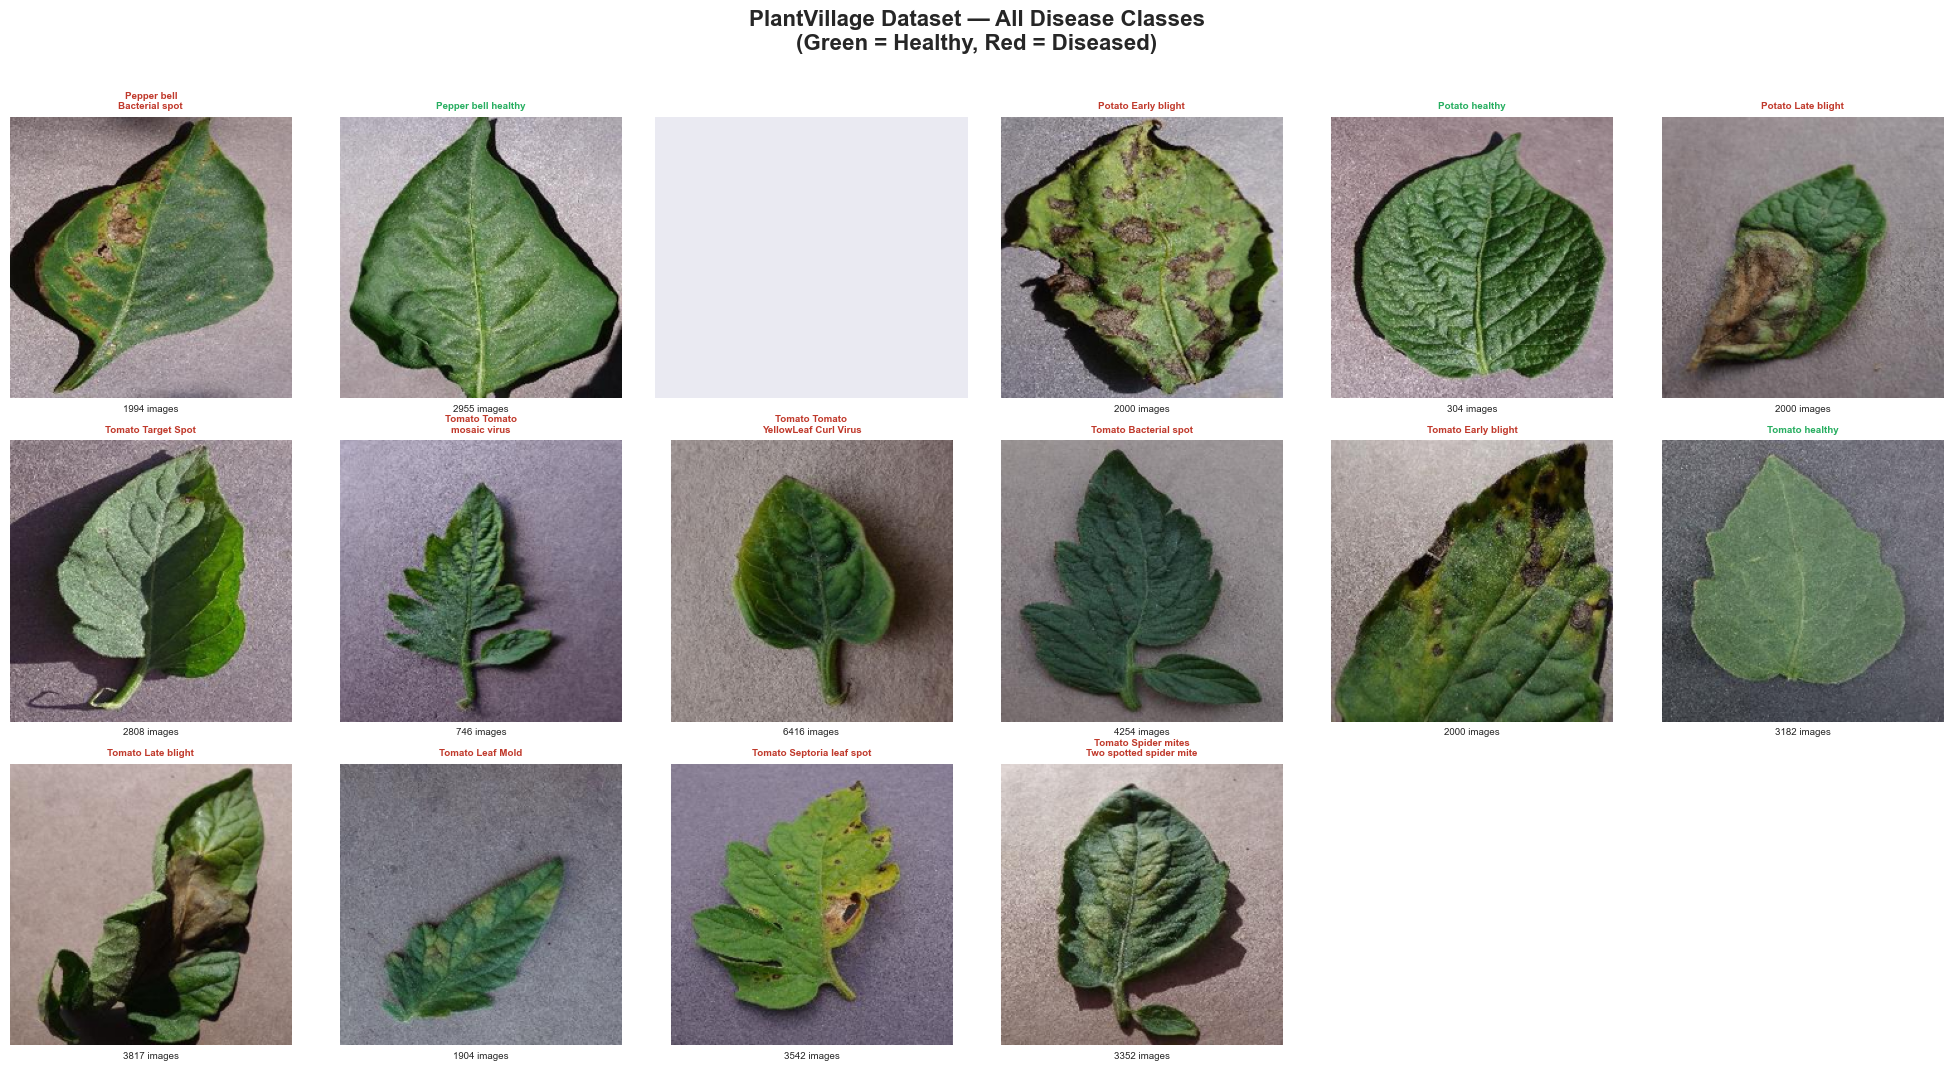

✓ Sample images saved to data/sample_images.png


In [6]:
# ============================================================
# CELL 6: Display sample images from each disease class
# This is the most exciting cell — you'll SEE the diseases!
# ============================================================

print("Displaying sample leaf images from each disease class...")

# How many classes do we have?
num_classes = len(df)

# We'll show 1 sample image per class
# Calculate grid dimensions
cols = 6   # 6 images per row
rows = (num_classes + cols - 1) // cols  # ceiling division

# Create a large figure
fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 3.5))

# Flatten 2D array of axes into 1D for easy looping
axes_flat = axes.flatten()

for idx, (_, row) in enumerate(df.iterrows()):
    ax = axes_flat[idx]
    
    # Get a sample image from this class
    class_folder = DATASET_PATH / row['class_name']
    images = (list(class_folder.glob('*.jpg')) + 
              list(class_folder.glob('*.JPG')))
    
    if images:
        # Open and display the image
        img = Image.open(images[0])
        
        # Resize for display (keeps it fast)
        img_display = img.resize((224, 224))
        
        ax.imshow(img_display)
        
        # Color the title: green for healthy, red for diseased
        title_color = '#27ae60' if row['is_healthy'] else '#c0392b'
        
        # Clean up the class name for display
        # Replace underscores with spaces, limit length
        clean_name = row['class_name'].replace('___', ' ').replace('__', ' ').replace('_', ' ')
        
        # Wrap long titles
        if len(clean_name) > 25:
            words = clean_name.split()
            mid = len(words) // 2
            clean_name = ' '.join(words[:mid]) + '\n' + ' '.join(words[mid:])
        
        ax.set_title(clean_name, fontsize=7, color=title_color, fontweight='bold')
        ax.set_xlabel(f"{row['image_count']} images", fontsize=7)
    
    # Remove axis ticks (they look messy on image grids)
    ax.set_xticks([])
    ax.set_yticks([])

# Hide any unused subplot slots
for idx in range(len(df), len(axes_flat)):
    axes_flat[idx].set_visible(False)

# Add a main title
fig.suptitle('PlantVillage Dataset — All Disease Classes\n(Green = Healthy, Red = Diseased)', 
             fontsize=16, fontweight='bold', y=1.01)

plt.tight_layout()
plt.savefig('../../data/sample_images.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"✓ Sample images saved to data/sample_images.png")

In [7]:
# ============================================================
# CELL 7: Final summary — what did we learn about our data?
# ============================================================

print("=" * 60)
print("  DAY 2 COMPLETE — DATASET ANALYSIS REPORT")
print("=" * 60)

total_images = df['image_count'].sum()
healthy_images = df[df['is_healthy']]['image_count'].sum()
diseased_images = df[~df['is_healthy']]['image_count'].sum()

print(f"""
📊 DATASET STATISTICS:
   Total images     : {total_images:,}
   Healthy images   : {healthy_images:,} ({healthy_images/total_images*100:.1f}%)
   Diseased images  : {diseased_images:,} ({diseased_images/total_images*100:.1f}%)
   Total classes    : {len(df)}
   Plants covered   : {df['plant'].nunique()}

🌿 PLANTS IN DATASET:
""")

# Per-plant breakdown
for plant, group in df.groupby('plant'):
    total = group['image_count'].sum()
    diseases = len(group[~group['is_healthy']])
    print(f"   {plant:10} : {total:5,} images | {diseases} diseases")

print(f"""
⚠️  THINGS TO WATCH IN TRAINING:
   • Some classes have fewer images — model might struggle with these
   • We'll use augmentation on Day 3 to balance this out
   • All images need resizing to 224x224 before training

✅ WHAT WE CONFIRMED:
   • Dataset path    : {DATASET_PATH}
   • Image format    : JPG (mostly), consistent quality
   • Classes clearly : separated into folders (easy to load)
   • Ready for       : Day 3 preprocessing pipeline!
""")

# Save the dataset info as CSV for reference
df.to_csv('../../data/dataset_info.csv', index=False)
print("✓ Dataset info saved to data/dataset_info.csv")
print("\n🚀 Ready for Day 3: Building the Data Pipeline!")

  DAY 2 COMPLETE — DATASET ANALYSIS REPORT

📊 DATASET STATISTICS:
   Total images     : 41,274
   Healthy images   : 6,441 (15.6%)
   Diseased images  : 34,833 (84.4%)
   Total classes    : 16
   Plants covered   : 4

🌿 PLANTS IN DATASET:

   Pepper     : 4,949 images | 1 diseases
   PlantVillage :     0 images | 1 diseases
   Potato     : 4,304 images | 2 diseases
   Tomato     : 32,021 images | 9 diseases

⚠️  THINGS TO WATCH IN TRAINING:
   • Some classes have fewer images — model might struggle with these
   • We'll use augmentation on Day 3 to balance this out
   • All images need resizing to 224x224 before training

✅ WHAT WE CONFIRMED:
   • Dataset path    : ..\..\data\raw\PlantVillage
   • Image format    : JPG (mostly), consistent quality
   • Classes clearly : separated into folders (easy to load)
   • Ready for       : Day 3 preprocessing pipeline!

✓ Dataset info saved to data/dataset_info.csv

🚀 Ready for Day 3: Building the Data Pipeline!
